<a href="https://colab.research.google.com/github/Aldors37/2318046_DataCleansingCafeSales/blob/main/2318046DataCleansing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import library yang diperlukan

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Menampilkan semua kolom pada dataframe
pd.set_option('display.max_columns', None)

print("Library berhasil di-import!")

Library berhasil di-import!


In [2]:
from google.colab import files

uploaded = files.upload()

Saving dirty_cafe_sales.csv to dirty_cafe_sales.csv


In [3]:
# Membaca dataset
df = pd.read_csv('dirty_cafe_sales.csv')

print("Dataset berhasil dibaca!")

Dataset berhasil dibaca!


In [4]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [5]:
df.tail()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02
9999,TXN_6170729,Sandwich,3,4.0,12.0,Cash,In-store,2023-11-07


In [6]:
# Menampilkan jumlah baris dan kolom
print("Jumlah baris  :", df.shape[0])
print("Jumlah kolom  :", df.shape[1])

Jumlah baris  : 10000
Jumlah kolom  : 8


In [7]:
print("Nama kolom:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Nama kolom:
1. Transaction ID
2. Item
3. Quantity
4. Price Per Unit
5. Total Spent
6. Payment Method
7. Location
8. Transaction Date


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [9]:
df.describe(include='all').T

,count,unique,top,freq
Transaction ID,10000,10000,TXN_9226047,1
Item,9667,10,Juice,1171
Quantity,9862,7,5,2013
Price Per Unit,9821,8,3.0,2429
Total Spent,9827,19,6.0,979
Payment Method,7421,5,Digital Wallet,2291
Location,6735,4,Takeaway,3022
Transaction Date,9841,367,UNKNOWN,159


In [10]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    'Kolom': missing.index,
    'Jumlah Missing': missing.values,
    'Persentase (%)': (missing.values / len(df) * 100).round(2)
})

missing_df

,Kolom,Jumlah Missing,Persentase (%)
0,Transaction ID,0,0.00
1,Item,333,3.33
2,Quantity,138,1.38
3,Price Per Unit,179,1.79
4,Total Spent,173,1.73
5,Payment Method,2579,25.79
6,Location,3265,32.65
7,Transaction Date,159,1.59


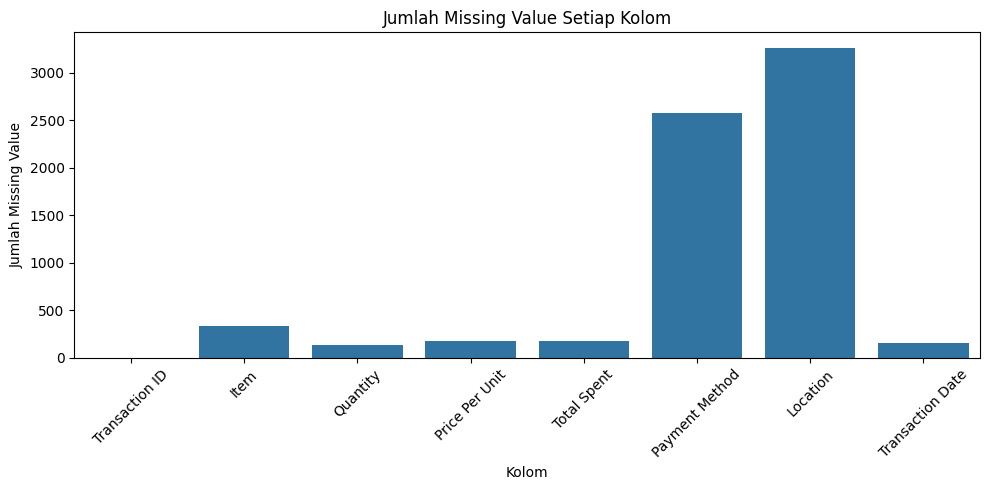

In [11]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=missing_df['Kolom'],
    y=missing_df['Jumlah Missing']
)

plt.title('Jumlah Missing Value Setiap Kolom')
plt.xlabel('Kolom')
plt.ylabel('Jumlah Missing Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
jumlah_duplikat = df.duplicated().sum()

print("Jumlah data duplikat:", jumlah_duplikat)

Jumlah data duplikat: 0


In [13]:
# Menghitung UNKNOWN dan ERROR pada setiap kolom

hasil_unknown_error = pd.DataFrame({
    'UNKNOWN': [(df[col] == 'UNKNOWN').sum() for col in df.columns],
    'ERROR': [(df[col] == 'ERROR').sum() for col in df.columns]
}, index=df.columns)

hasil_unknown_error

,UNKNOWN,ERROR
Transaction ID,0,0
Item,344,292
Quantity,171,170
Price Per Unit,164,190
Total Spent,165,164
Payment Method,293,306
Location,338,358
Transaction Date,159,142


In [14]:
for column in df.columns:
    print("=" * 60)
    print(f"Kolom: {column}")
    print("Jumlah nilai unik:", df[column].nunique())
    print("Contoh nilai:")
    print(df[column].unique()[:20])

Kolom: Transaction ID
Jumlah nilai unik: 10000
Contoh nilai:
['TXN_1961373' 'TXN_4977031' 'TXN_4271903' 'TXN_7034554' 'TXN_3160411'
 'TXN_2602893' 'TXN_4433211' 'TXN_6699534' 'TXN_4717867' 'TXN_2064365'
 'TXN_2548360' 'TXN_3051279' 'TXN_7619095' 'TXN_9437049' 'TXN_8915701'
 'TXN_2847255' 'TXN_3765707' 'TXN_6769710' 'TXN_8876618' 'TXN_3709394']
Kolom: Item
Jumlah nilai unik: 10
Contoh nilai:
['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie' 'UNKNOWN' 'Sandwich' nan
 'ERROR' 'Juice' 'Tea']
Kolom: Quantity
Jumlah nilai unik: 7
Contoh nilai:
['2' '4' '5' '3' '1' 'ERROR' 'UNKNOWN' nan]
Kolom: Price Per Unit
Jumlah nilai unik: 8
Contoh nilai:
['2.0' '3.0' '1.0' '5.0' '4.0' '1.5' nan 'ERROR' 'UNKNOWN']
Kolom: Total Spent
Jumlah nilai unik: 19
Contoh nilai:
['4.0' '12.0' 'ERROR' '10.0' '20.0' '9.0' '16.0' '15.0' '25.0' '8.0' '5.0'
 '3.0' '6.0' nan 'UNKNOWN' '2.0' '1.0' '7.5' '4.5' '1.5']
Kolom: Payment Method
Jumlah nilai unik: 5
Contoh nilai:
['Credit Card' 'Cash' 'UNKNOWN' 'Digital Wallet' 'ERROR

In [15]:
categorical_columns = [
    'Item',
    'Payment Method',
    'Location'
]

for column in categorical_columns:
    print("=" * 60)
    print(f"Distribusi: {column}")
    print(df[column].value_counts(dropna=False))

Distribusi: Item
Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
UNKNOWN      344
NaN          333
ERROR        292
Name: count, dtype: int64
Distribusi: Payment Method
Payment Method
NaN               2579
Digital Wallet    2291
Credit Card       2273
Cash              2258
ERROR              306
UNKNOWN            293
Name: count, dtype: int64
Distribusi: Location
Location
NaN         3265
Takeaway    3022
In-store    3017
ERROR        358
UNKNOWN      338
Name: count, dtype: int64


In [16]:
numeric_columns = [
    'Quantity',
    'Price Per Unit',
    'Total Spent'
]

for column in numeric_columns:
    print("=" * 60)
    print(f"Kolom: {column}")
    print(df[column].value_counts(dropna=False).head(20))

Kolom: Quantity
Quantity
5          2013
2          1974
4          1863
3          1849
1          1822
UNKNOWN     171
ERROR       170
NaN         138
Name: count, dtype: int64
Kolom: Price Per Unit
Price Per Unit
3.0        2429
4.0        2331
2.0        1227
5.0        1204
1.0        1143
1.5        1133
ERROR       190
NaN         179
UNKNOWN     164
Name: count, dtype: int64
Kolom: Total Spent
Total Spent
6.0        979
12.0       939
3.0        930
4.0        923
20.0       746
15.0       734
8.0        677
10.0       524
2.0        497
9.0        479
5.0        468
16.0       444
25.0       259
7.5        237
1.0        232
4.5        225
1.5        205
NaN        173
UNKNOWN    165
ERROR      164
Name: count, dtype: int64


In [17]:
print("===== RINGKASAN DATASET =====")
print(f"Jumlah baris          : {df.shape[0]}")
print(f"Jumlah kolom          : {df.shape[1]}")
print(f"Jumlah data duplikat  : {df.duplicated().sum()}")
print(f"Total missing value   : {df.isnull().sum().sum()}")

print("\nJumlah UNKNOWN:")
print((df == 'UNKNOWN').sum().sum())

print("\nJumlah ERROR:")
print((df == 'ERROR').sum().sum())

print("\nTipe data:")
print(df.dtypes)

===== RINGKASAN DATASET =====
Jumlah baris          : 10000
Jumlah kolom          : 8
Jumlah data duplikat  : 0
Total missing value   : 6826

Jumlah UNKNOWN:
1634

Jumlah ERROR:
1622

Tipe data:
Transaction ID      object
Item                object
Quantity            object
Price Per Unit      object
Total Spent         object
Payment Method      object
Location            object
Transaction Date    object
dtype: object


In [18]:
# Membuat salinan dataset untuk proses cleansing
df_clean = df.copy()

print("Salinan dataset berhasil dibuat.")
print("Jumlah baris :", df_clean.shape[0])
print("Jumlah kolom :", df_clean.shape[1])

Salinan dataset berhasil dibuat.
Jumlah baris : 10000
Jumlah kolom : 8


In [19]:
# Mengubah nilai UNKNOWN dan ERROR menjadi NaN
df_clean = df_clean.replace(['UNKNOWN', 'ERROR'], np.nan)

print("UNKNOWN dan ERROR berhasil dikonversi menjadi missing value.")

UNKNOWN dan ERROR berhasil dikonversi menjadi missing value.


In [20]:
# Mengecek jumlah missing value setelah UNKNOWN dan ERROR dikonversi
missing_after_replace = pd.DataFrame({
    'Kolom': df_clean.columns,
    'Jumlah Missing': df_clean.isnull().sum(),
    'Persentase (%)': (df_clean.isnull().sum() / len(df_clean) * 100).round(2)
})

missing_after_replace

,Kolom,Jumlah Missing,Persentase (%)
Transaction ID,Transaction ID,0,0.00
Item,Item,969,9.69
Quantity,Quantity,479,4.79
Price Per Unit,Price Per Unit,533,5.33
Total Spent,Total Spent,502,5.02
Payment Method,Payment Method,3178,31.78
Location,Location,3961,39.61
Transaction Date,Transaction Date,460,4.60


In [21]:
# Konversi kolom numerik
numeric_columns = [
    'Quantity',
    'Price Per Unit',
    'Total Spent'
]

for column in numeric_columns:
    df_clean[column] = pd.to_numeric(
        df_clean[column],
        errors='coerce'
    )

# Konversi kolom tanggal
df_clean['Transaction Date'] = pd.to_datetime(
    df_clean['Transaction Date'],
    errors='coerce'
)

print("Konversi tipe data selesai.")

Konversi tipe data selesai.


In [22]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    10000 non-null  object        
 1   Item              9031 non-null   object        
 2   Quantity          9521 non-null   float64       
 3   Price Per Unit    9467 non-null   float64       
 4   Total Spent       9498 non-null   float64       
 5   Payment Method    6822 non-null   object        
 6   Location          6039 non-null   object        
 7   Transaction Date  9540 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), object(4)
memory usage: 625.1+ KB


In [23]:
missing_check = pd.DataFrame({
    'Jumlah Missing': df_clean.isnull().sum(),
    'Persentase (%)': (
        df_clean.isnull().sum() / len(df_clean) * 100
    ).round(2)
})

missing_check

,Jumlah Missing,Persentase (%)
Transaction ID,0,0.00
Item,969,9.69
Quantity,479,4.79
Price Per Unit,533,5.33
Total Spent,502,5.02
Payment Method,3178,31.78
Location,3961,39.61
Transaction Date,460,4.60


In [24]:
print("Jumlah data duplikat sebelum cleaning :", df.duplicated().sum())
print("Jumlah data duplikat setelah cleaning :", df_clean.duplicated().sum())

Jumlah data duplikat sebelum cleaning : 0
Jumlah data duplikat setelah cleaning : 0


In [25]:
# Menangani missing value

# Item → modus
df_clean['Item'] = df_clean['Item'].fillna(df_clean['Item'].mode()[0])

# Quantity → median
df_clean['Quantity'] = df_clean['Quantity'].fillna(df_clean['Quantity'].median())

# Price Per Unit → berdasarkan Item
price_mapping = {
    'Cookie': 1.0, 'Tea': 1.5, 'Coffee': 2.0,
    'Cake': 3.0, 'Juice': 3.0, 'Sandwich': 4.0,
    'Smoothie': 4.0, 'Salad': 5.0
}

df_clean['Price Per Unit'] = df_clean['Price Per Unit'].fillna(
    df_clean['Item'].map(price_mapping)
)

# Sisa harga → median
df_clean['Price Per Unit'] = df_clean['Price Per Unit'].fillna(
    df_clean['Price Per Unit'].median()
)

# Total Spent → Quantity × Price
df_clean['Total Spent'] = df_clean['Total Spent'].fillna(
    df_clean['Quantity'] * df_clean['Price Per Unit']
)

# Sisa Total Spent → median
df_clean['Total Spent'] = df_clean['Total Spent'].fillna(
    df_clean['Total Spent'].median()
)

# Data kategorikal
df_clean['Payment Method'] = df_clean['Payment Method'].fillna('Unknown')
df_clean['Location'] = df_clean['Location'].fillna('Unknown')

# Tanggal → median
df_clean['Transaction Date'] = df_clean['Transaction Date'].fillna(
    df_clean['Transaction Date'].median()
)

print("Missing value berhasil ditangani!")
print("Total missing:", df_clean.isnull().sum().sum())

Missing value berhasil ditangani!
Total missing: 0


In [26]:
# Cek data tidak valid dan outlier

print("=== Data Tidak Valid ===")
print("Quantity <= 0 :", (df_clean['Quantity'] <= 0).sum())
print("Price <= 0    :", (df_clean['Price Per Unit'] <= 0).sum())
print("Total <= 0    :", (df_clean['Total Spent'] <= 0).sum())

print("\n=== Outlier ===")
for col in ['Quantity', 'Price Per Unit', 'Total Spent']:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    print(f"{col}: {outlier} outlier")

=== Data Tidak Valid ===
Quantity <= 0 : 0
Price <= 0    : 0
Total <= 0    : 0

=== Outlier ===
Quantity: 0 outlier
Price Per Unit: 0 outlier
Total Spent: 269 outlier


In [27]:
# Melihat nilai Total Spent yang dianggap outlier

Q1 = df_clean['Total Spent'].quantile(0.25)
Q3 = df_clean['Total Spent'].quantile(0.75)
IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR

outlier_total = df_clean[df_clean['Total Spent'] > upper]

print("Batas atas outlier:", upper)
print("Jumlah outlier:", len(outlier_total))

outlier_total[['Item', 'Quantity', 'Price Per Unit', 'Total Spent']].head(20)

Batas atas outlier: 24.0
Jumlah outlier: 269


,Item,Quantity,Price Per Unit,Total Spent
10,Salad,5.0,5.0,25.0
51,Salad,5.0,5.0,25.0
52,Juice,5.0,5.0,25.0
96,Salad,5.0,5.0,25.0
100,Juice,5.0,5.0,25.0
150,Salad,5.0,5.0,25.0
157,Salad,5.0,5.0,25.0
177,Salad,3.0,5.0,25.0
214,Salad,3.0,5.0,25.0
330,Salad,5.0,5.0,25.0


In [28]:
# Validasi Total Spent

hitung_total = df_clean['Quantity'] * df_clean['Price Per Unit']

tidak_sesuai = (df_clean['Total Spent'] != hitung_total).sum()

print("Data Total Spent tidak sesuai:", tidak_sesuai)

Data Total Spent tidak sesuai: 396


In [29]:
# Memperbaiki Total Spent yang tidak sesuai
hitung_total = df_clean['Quantity'] * df_clean['Price Per Unit']

mask = df_clean['Total Spent'] != hitung_total

df_clean.loc[mask, 'Total Spent'] = hitung_total[mask]

print("Total Spent berhasil diperbaiki.")
print("Data yang diperbaiki:", mask.sum())

Total Spent berhasil diperbaiki.
Data yang diperbaiki: 396


In [30]:
# Validasi ulang
hitung_total = df_clean['Quantity'] * df_clean['Price Per Unit']

print(
    "Total Spent tidak sesuai:",
    (df_clean['Total Spent'] != hitung_total).sum()
)

Total Spent tidak sesuai: 0


# Data Enrichment

In [31]:
# Data Enrichment

# Menambahkan informasi waktu
df_clean['Year'] = df_clean['Transaction Date'].dt.year
df_clean['Month'] = df_clean['Transaction Date'].dt.month
df_clean['Day'] = df_clean['Transaction Date'].dt.day
df_clean['Day of Week'] = df_clean['Transaction Date'].dt.day_name()

# Menambahkan kategori transaksi
df_clean['Revenue Category'] = pd.cut(
    df_clean['Total Spent'],
    bins=[0, 10, 20, np.inf],
    labels=['Rendah', 'Sedang', 'Tinggi']
)

print("Data enrichment berhasil!")
df_clean.head()

Data enrichment berhasil!


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,Day,Day of Week,Revenue Category
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,2023,9,8,Friday,Rendah
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,2023,5,16,Tuesday,Sedang
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19,2023,7,19,Wednesday,Rendah
3,TXN_7034554,Salad,2.0,5.0,10.0,Unknown,Unknown,2023-04-27,2023,4,27,Thursday,Rendah
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,2023,6,11,Sunday,Rendah


In [32]:
print("===== HASIL AKHIR =====")
print("Data awal              :", df.shape)
print("Data setelah proses    :", df_clean.shape)
print("Missing value          :", df_clean.isnull().sum().sum())
print("Data duplikat          :", df_clean.duplicated().sum())
print("Total kolom enrichment:", 5)

===== HASIL AKHIR =====
Data awal              : (10000, 8)
Data setelah proses    : (10000, 13)
Missing value          : 0
Data duplikat          : 0
Total kolom enrichment: 5


In [33]:
# Menyimpan dataset hasil cleansing dan enrichment
df_clean.to_csv('cafe_sales_clean_enriched.csv', index=False)

print("Dataset berhasil disimpan!")

Dataset berhasil disimpan!


In [34]:
from google.colab import files

files.download('cafe_sales_clean_enriched.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>